# Teste de Baseline com rede neural artificial para predição de resistência à compressão

In [1]:
%%capture
!pip install optuna

In [2]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GroupKFold
import matplotlib.pyplot as plt
from google.colab import drive
from tqdm.notebook import tqdm
from scipy import stats
import seaborn as sns
import pandas as pd
import numpy as np
import os, optuna

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'

# Regressão neural
rna_file = 'df_resistencia_MLP.pkl'
rna_path = os.path.join(dirpath, rna_file)

df_rna = pd.read_pickle(rna_path)
df_rna['target'] = df_rna['Resistencia_Compressao_MPa'].copy()
df_rna.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])

In [5]:
n_groups = df_rna['Autores/ano'].nunique()
print(f"Número de grupos únicos (Autores/ano): {n_groups}")
gkf = GroupKFold(n_splits=n_groups)

Número de grupos únicos (Autores/ano): 17


In [6]:
X = df_rna.drop(
    columns=["target", "Autores/ano"]
)

y = df_rna["target"]
groups = df_rna["Autores/ano"]

def objective(trial):
    rmse_scores = []
    n_layers = trial.suggest_int('n_layers', 2, 3)

    layer1 = trial.suggest_int('layer1', 20, 80)

    layer2 = trial.suggest_int(
        'layer2',
        5,
        layer1
    )

    if n_layers == 2:
        hidden_layer_sizes = (
            layer1,
            layer2
        )
    else:
        layer3 = trial.suggest_int(
            'layer3',
            3,
            layer2
        )

        hidden_layer_sizes = (
            layer1,
            layer2,
            layer3
        )

    hyperparams = {
        'hidden_layer_sizes': hidden_layer_sizes,
        'activation': 'tanh',
        'solver': 'lbfgs',
        'alpha': trial.suggest_float(
            'alpha',
            350,
            650,
            log=True
        ),
        'max_iter': 9000,
        'random_state': 42
    }

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        model = MLPRegressor(**hyperparams)

        model.fit(X_train, y_train)

        preds = model.predict(X_val)

        rmse = root_mean_squared_error(y_val, preds)
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)


# ==========================================
# EXECUTANDO O ESTUDO
# ==========================================
n_trials = 250

pbar = tqdm(total=n_trials, desc="Otimizando Hiperparâmetros", unit="trial")

def tqdm_callback(study, trial):
    pbar.update(1)
    pbar.set_postfix({
        "best_rmse": f"{study.best_value:.4f}"
    })

study_rna = optuna.create_study(
    direction="minimize",
    study_name="Tuning_Concreto"
)

study_rna.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[tqdm_callback]
)

pbar.close()

print(f"Melhor RMSE alcançado (Cross-Validation): {study_rna.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study_rna.best_params.items():
    print(f"  '{key}': {value},")

In [8]:
best_params = {
    'hidden_layer_sizes': (74, 65),
    'alpha': 360.24104049891264,
    'activation': 'tanh',
    'solver': 'lbfgs',
    'max_iter': 9000,
    'random_state': 42
}

In [10]:
all_preds = []
all_true = []
all_groups = []

X = df_rna.drop(
    columns=["target", "Autores/ano"]
)

y = df_rna["target"]
groups = df_rna["Autores/ano"]

for fold, (train_idx, val_idx) in tqdm(enumerate(
    gkf.split(X, y, groups)), desc="Executando treinamento...", unit="Fold", total=len(gkf.split(X, y, groups))):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = MLPRegressor(**best_params)

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    all_preds.extend(preds)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])

Executando treinamento...: 0Fold [00:00, ?Fold/s]

In [11]:
mlp_results = pd.DataFrame({
    "y_true": all_true,
    "y_pred": all_preds,
    "group": all_groups
})

mlp_results["residual"] = (
    mlp_results["y_true"] -
    mlp_results["y_pred"]
)

mlp_results["abs_error"] = (
    mlp_results["residual"].abs()
)

## Observado vs Predito

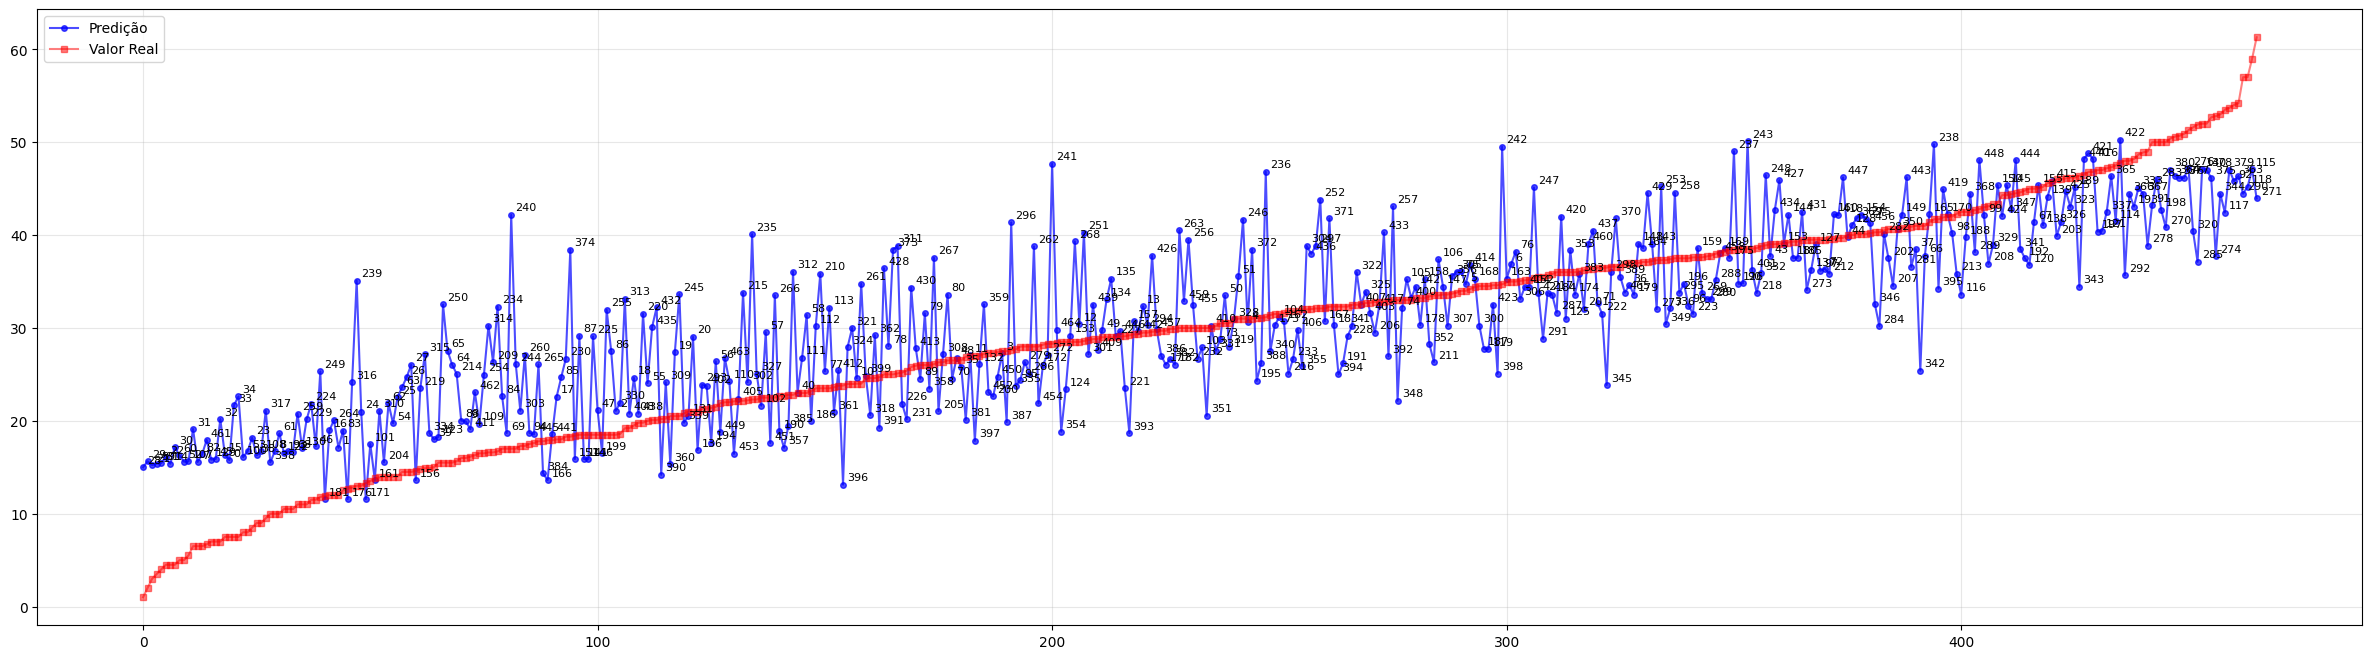

In [12]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = mlp_results.sort_values(by="y_true")
indices = range(len(debug_df))

plt.figure(figsize=(30, 8))

plt.plot(
    indices,
    debug_df["y_pred"],
    color='blue',
    label="Predição",
    alpha=0.7,
    linewidth=1.5,
    marker='o',
    markersize=4
)

plt.plot(
    indices,
    debug_df["y_true"],
    color='red',
    label="Valor Real",
    alpha=0.5,
    linewidth=1.5,
    marker='s',
    markersize=4
)

for x, y, idx in zip(
    indices,
    debug_df["y_pred"],
    debug_df.index
):
    plt.annotate(
        str(idx),
        (x, y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Distribuição dos residuos

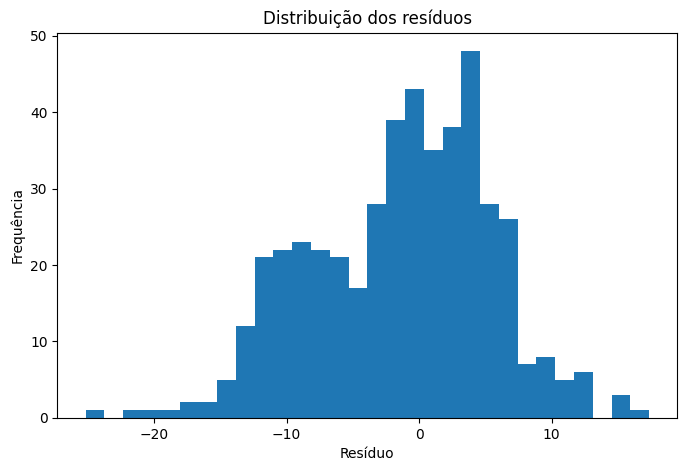

In [13]:
plt.figure(figsize=(8,5))

plt.hist(
    mlp_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

## Residuo vs Predito

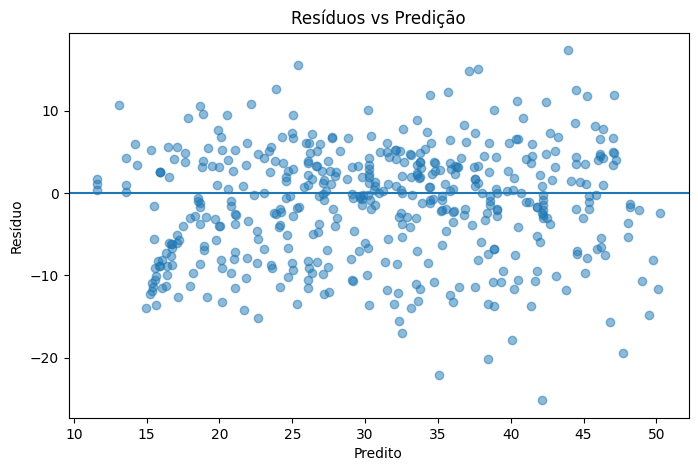

In [14]:
plt.figure(figsize=(8,5))

plt.scatter(
    mlp_results["y_pred"],
    mlp_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

## Erro Medio por grupo

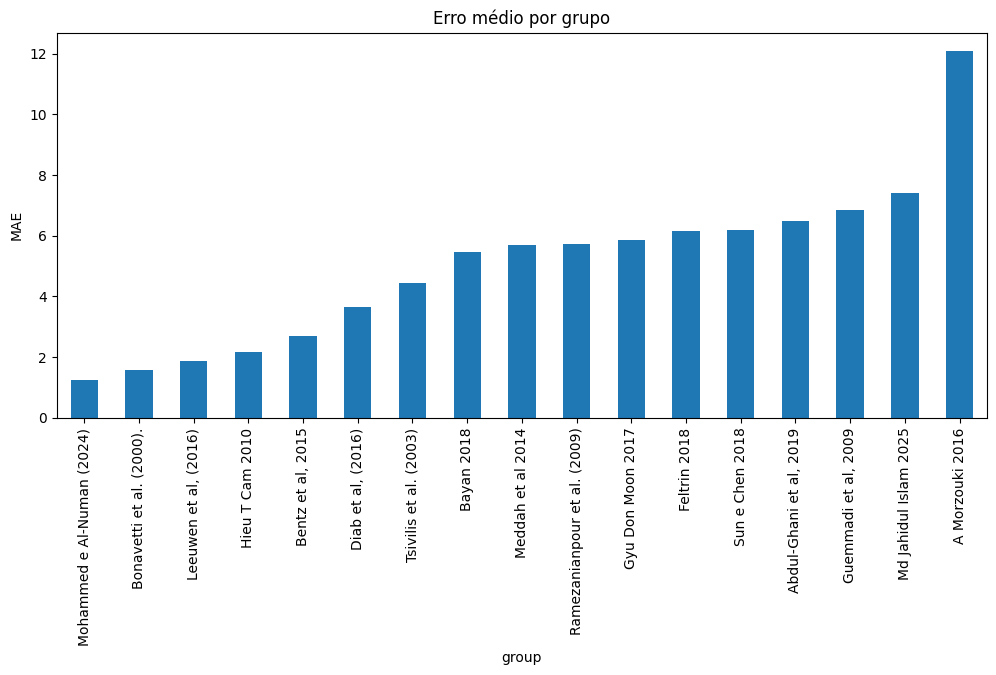

In [15]:
group_errors = (
    mlp_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [16]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 6.9423
mean_absolute_error: 5.4888
mean_absolute_percentage_error: 0.3428
R² Score: 67.4132
